# Thrivelines from a saved correlation matrix

Thrivelines show how a z-score is expected to evolve over one covariate step
(by default, one year). To estimate them we need to know the correlation matrix (= how strongly z-scores correlate across ages).

In pcntoolkit the correlation matrix lives in the `CorrelationMatrix` class, and everything downstream, scoring subjects and drawing
thrivelines, needs only that matrix plus a fitted normative model.

In this notebook we plot thrivelines using a precomputed correlation matrix. The matrix already carries everything learned from a longitudinal cohort, so no longitudinal data is needed to plot them.

> **Note:** the normative model is downloaded automatically from SURFdrive, but the correlation matrix exists in a private directory.

In [5]:
import matplotlib.pyplot as plt
import numpy as np



from pcntoolkit import CorrelationMatrix, NormativeModel, ZGainScore
from pcntoolkit.util.plotter import plot_thrivelines

In [6]:
from scipy import stats
import warnings
from pandas.errors import PerformanceWarning

In [7]:
MODEL_PATH= '/project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity/CODE_new/revision/save_dir_DES_ADNI_demented_revision/'

model = NormativeModel.load(str(MODEL_PATH))
print("covariates:   ", model.covariates)
print("response vars:", list(model.response_vars))

/home/preclineu/johbay/.conda/envs/pcntoolkit_velocity/lib/python3.12/site-packages/pcntoolkit/util/output.py:309: UserWarning: Process: 2057996 - 2026-09-11 20:11:25 - This model was saved with PCNtoolkit v1.1.2, but you are running v1.3.0. Loading this model in v1.3.0...
  warnings.warn(message, category)
/home/preclineu/johbay/.conda/envs/pcntoolkit_velocity/lib/python3.12/site-packages/pcntoolkit/util/output.py:309: UserWarning: Process: 2057996 - 2026-09-11 20:11:26 - This model was saved with PCNtoolkit v1.1.2, but you are running v1.3.0. Loading this model in v1.3.0...
  warnings.warn(message, category)
/home/preclineu/johbay/.conda/envs/pcntoolkit_velocity/lib/python3.12/site-packages/pcntoolkit/util/output.py:309: UserWarning: Process: 2057996 - 2026-09-11 20:11:26 - This model was saved with PCNtoolkit v1.1.2, but you are running v1.3.0. Loading this model in v1.3.0...
  warnings.warn(message, category)
/home/preclineu/johbay/.conda/envs/pcntoolkit_velocity/lib/python3.12/sit

covariates:    ['age']
response vars: ['rh_G_parietal_sup', 'lh_S_circular_insula_inf', 'rh_S_temporal_inf', 'lh_S_precentral-sup-part', 'lh_G_front_middle', 'rh_S_cingul-Marginalis', 'rh_G_and_S_occipital_inf', 'rh_Pole_occipital', 'lh_S_orbital_med-olfact', 'rh_S_precentral-sup-part', 'rh_S_oc-temp_lat', 'lh_G_and_S_transv_frontopol', 'lh_S_collat_transv_post', 'lh_S_circular_insula_sup', 'rh_S_postcentral', 'lh_S_parieto_occipital', 'lh_S_front_inf', 'lh_G_postcentral', 'rh_G_front_inf-Triangul', 'lh_G_rectus', 'lh_S_postcentral', 'rh_G_cingul-Post-ventral', 'rh_S_circular_insula_sup', 'lh_G_and_S_subcentral', 'rh_G_front_middle', 'lh_S_temporal_inf', 'lh_S_orbital_lateral', 'lh_S_circular_insula_ant', 'rh_S_orbital_lateral', 'lh_G_and_S_frontomargin', 'rh_G_and_S_cingul-Ant', 'lh_G_precuneus', 'rh_G_rectus', 'lh_S_oc_middle_and_Lunatus', 'rh_S_circular_insula_inf', 'lh_Pole_occipital', 'rh_G_temporal_middle', 'rh_S_oc-temp_med_and_Lingual', 'rh_S_front_inf', 'lh_G_front_sup', 'lh_G

/home/preclineu/johbay/.conda/envs/pcntoolkit_velocity/lib/python3.12/site-packages/pcntoolkit/util/output.py:309: UserWarning: Process: 2057996 - 2026-09-11 20:12:19 - This model was saved with PCNtoolkit v1.1.2, but you are running v1.3.0. Loading this model in v1.3.0...
  warnings.warn(message, category)


In [8]:
features_to_model = ['lh_G_and_S_frontomargin',
 'lh_G_and_S_occipital_inf',
 'lh_G_and_S_paracentral',
 'lh_G_and_S_subcentral',
 'lh_G_and_S_transv_frontopol',
 'lh_G_and_S_cingul-Ant',
 'lh_G_and_S_cingul-Mid-Ant',
 'lh_G_and_S_cingul-Mid-Post',
 'lh_G_cingul-Post-dorsal',
 'lh_G_cingul-Post-ventral',
 'lh_G_cuneus',
 'lh_G_front_inf-Opercular',
 'lh_G_front_inf-Orbital',
 'lh_G_front_inf-Triangul',
 'lh_G_front_middle',
 'lh_G_front_sup',
 'lh_G_Ins_lg_and_S_cent_ins',
 'lh_G_insular_short',
 'lh_G_occipital_middle',
 'lh_G_occipital_sup',
 'lh_G_oc-temp_lat-fusifor',
 'lh_G_oc-temp_med-Lingual',
 'lh_G_oc-temp_med-Parahip',
 'lh_G_orbital',
 'lh_G_pariet_inf-Angular',
 'lh_G_pariet_inf-Supramar',
 'lh_G_parietal_sup',
 'lh_G_postcentral',
 'lh_G_precentral',
 'lh_G_precuneus',
 'lh_G_rectus',
 'lh_G_subcallosal',
 'lh_G_temp_sup-G_T_transv',
 'lh_G_temp_sup-Lateral',
 'lh_G_temp_sup-Plan_polar',
 'lh_G_temp_sup-Plan_tempo',
 'lh_G_temporal_inf',
 'lh_G_temporal_middle',
 'lh_Lat_Fis-ant-Horizont',
 'lh_Lat_Fis-ant-Vertical',
 'lh_Lat_Fis-post',
 'lh_Pole_occipital',
 'lh_Pole_temporal',
 'lh_S_calcarine',
 'lh_S_central',
 'lh_S_cingul-Marginalis',
 'lh_S_circular_insula_ant',
 'lh_S_circular_insula_inf',
 'lh_S_circular_insula_sup',
 'lh_S_collat_transv_ant',
 'lh_S_collat_transv_post',
 'lh_S_front_inf',
 'lh_S_front_middle',
 'lh_S_front_sup',
 'lh_S_interm_prim-Jensen',
 'lh_S_intrapariet_and_P_trans',
 'lh_S_oc_middle_and_Lunatus',
 'lh_S_oc_sup_and_transversal',
 'lh_S_occipital_ant',
 'lh_S_oc-temp_lat',
 'lh_S_oc-temp_med_and_Lingual',
 'lh_S_orbital_lateral',
 'lh_S_orbital_med-olfact',
 'lh_S_orbital-H_Shaped',
 'lh_S_parieto_occipital',
 'lh_S_pericallosal',
 'lh_S_postcentral',
 'lh_S_precentral-inf-part',
 'lh_S_precentral-sup-part',
 'lh_S_suborbital',
 'lh_S_subparietal',
 'lh_S_temporal_inf',
 'lh_S_temporal_sup',
 'lh_S_temporal_transverse',
 'rh_G_and_S_frontomargin',
 'rh_G_and_S_occipital_inf',
 'rh_G_and_S_paracentral',
 'rh_G_and_S_subcentral',
 'rh_G_and_S_transv_frontopol',
 'rh_G_and_S_cingul-Ant',
 'rh_G_and_S_cingul-Mid-Ant',
 'rh_G_and_S_cingul-Mid-Post',
 'rh_G_cingul-Post-dorsal',
 'rh_G_cingul-Post-ventral',
 'rh_G_cuneus',
 'rh_G_front_inf-Opercular',
 'rh_G_front_inf-Orbital',
 'rh_G_front_inf-Triangul',
 'rh_G_front_middle',
 'rh_G_front_sup',
 'rh_G_Ins_lg_and_S_cent_ins',
 'rh_G_insular_short',
 'rh_G_occipital_middle',
 'rh_G_occipital_sup',
 'rh_G_oc-temp_lat-fusifor',
 'rh_G_oc-temp_med-Lingual',
 'rh_G_oc-temp_med-Parahip',
 'rh_G_orbital',
 'rh_G_pariet_inf-Angular',
 'rh_G_pariet_inf-Supramar',
 'rh_G_parietal_sup',
 'rh_G_postcentral',
 'rh_G_precentral',
 #'rh_G_precuneus',
 'rh_G_rectus',
 'rh_G_subcallosal',
 'rh_G_temp_sup-G_T_transv',
 'rh_G_temp_sup-Lateral',
 'rh_G_temp_sup-Plan_polar',
 'rh_G_temp_sup-Plan_tempo',
 'rh_G_temporal_inf',
 'rh_G_temporal_middle',
 'rh_Lat_Fis-ant-Horizont',
 'rh_Lat_Fis-ant-Vertical',
 'rh_Lat_Fis-post',
 'rh_Pole_occipital',
 'rh_Pole_temporal',
 'rh_S_calcarine',
 'rh_S_central',
 'rh_S_cingul-Marginalis',
 'rh_S_circular_insula_ant',
 'rh_S_circular_insula_inf',
 'rh_S_circular_insula_sup',
 'rh_S_collat_transv_ant',
 'rh_S_collat_transv_post',
 'rh_S_front_inf',
 'rh_S_front_middle',
 'rh_S_front_sup',
 'rh_S_interm_prim-Jensen',
 'rh_S_intrapariet_and_P_trans',
 'rh_S_oc_middle_and_Lunatus',
 'rh_S_oc_sup_and_transversal',
 'rh_S_occipital_ant',
 'rh_S_oc-temp_lat',
 'rh_S_oc-temp_med_and_Lingual',
 'rh_S_orbital_lateral',
 'rh_S_orbital_med-olfact',
 'rh_S_orbital-H_Shaped',
 'rh_S_parieto_occipital',
 'rh_S_pericallosal',
 'rh_S_postcentral',
 'rh_S_precentral-inf-part',
 'rh_S_precentral-sup-part',
 'rh_S_suborbital',
 'rh_S_subparietal',
 'rh_S_temporal_inf',
 'rh_S_temporal_sup',
 'rh_S_temporal_transverse',
 'Mean_Thickness',
 'Median_Thickness']

## 1. Load precomputed correlation matrix

`load()` loads only one specific file layout: the velocity models from Johanna
Bayer's pipeline, saved in `batch_<n>_<region>/Velocity/<file>.pkl`. The region name is not stored inside the file, so it is read from the directory name.

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:24:14 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:24:14 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:24:14 - Computing centiles for rh_G_precuneus.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


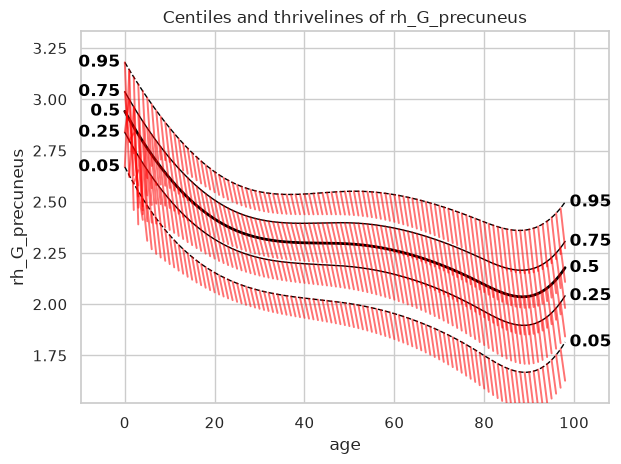

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:24:59 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:24:59 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:24:59 - Computing centiles for rh_G_rectus.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


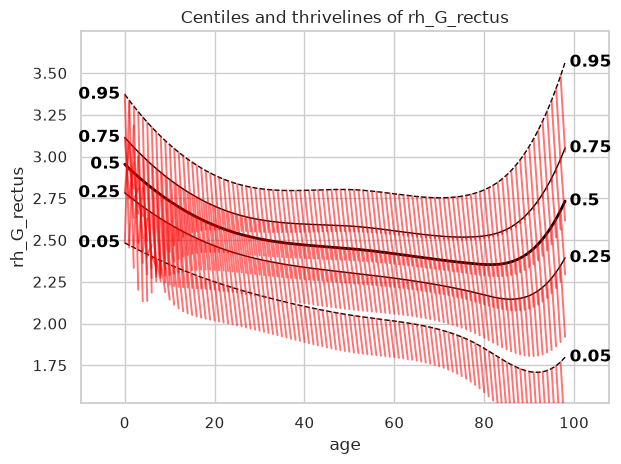

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:25:57 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:25:57 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:25:57 - Computing centiles for rh_G_subcallosal.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


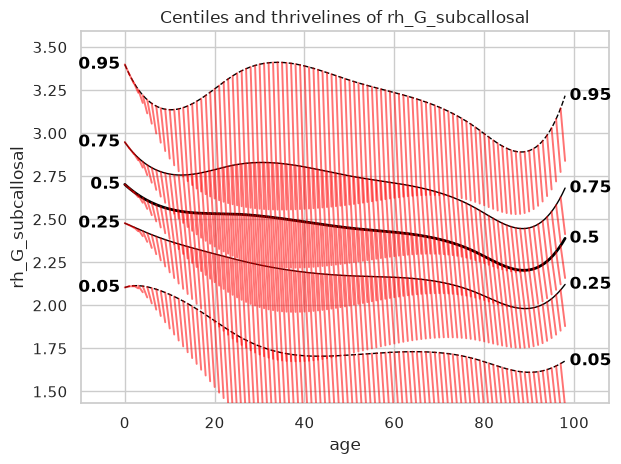

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:26:33 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:26:33 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:26:33 - Computing centiles for rh_G_temp_sup-G_T_transv.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


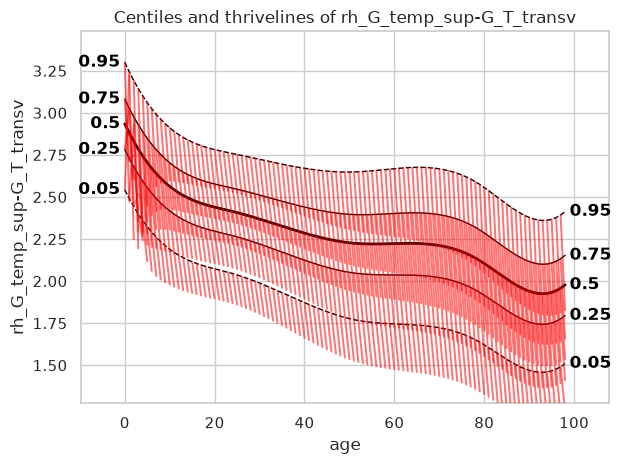

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:27:07 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:27:07 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:27:07 - Computing centiles for rh_G_temp_sup-Lateral.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


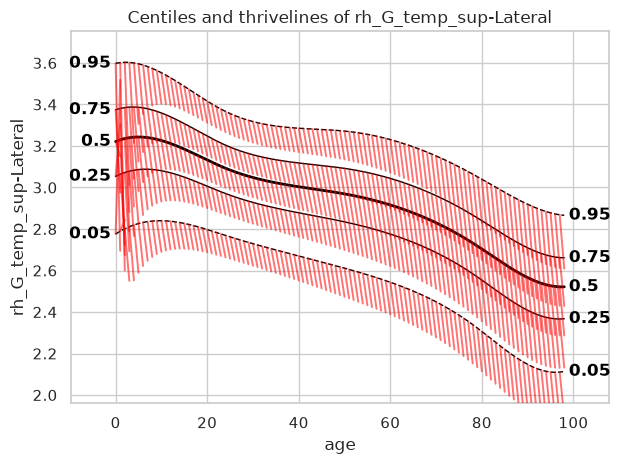

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:27:43 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:27:43 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:27:43 - Computing centiles for rh_G_temp_sup-Plan_polar.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


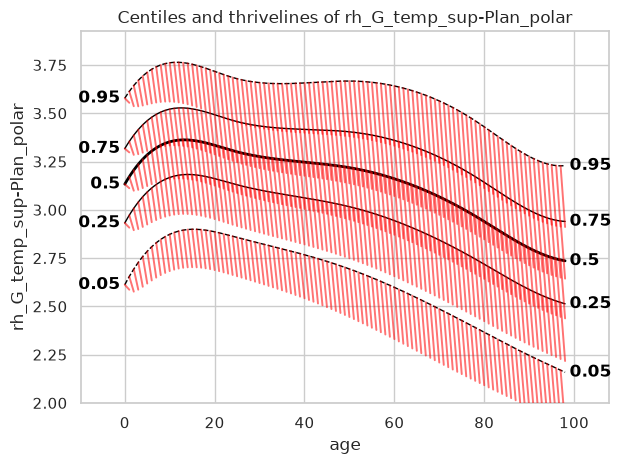

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:28:17 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:28:17 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:28:17 - Computing centiles for rh_G_temp_sup-Plan_tempo.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


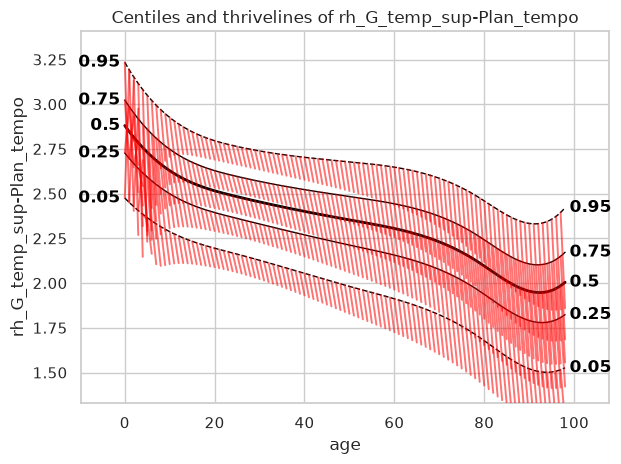

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:28:52 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:28:52 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:28:52 - Computing centiles for rh_G_temporal_inf.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


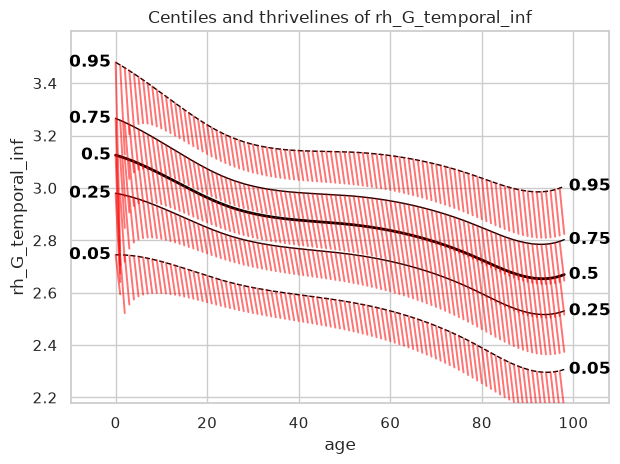

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:29:26 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:29:26 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:29:26 - Computing centiles for rh_G_temporal_middle.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


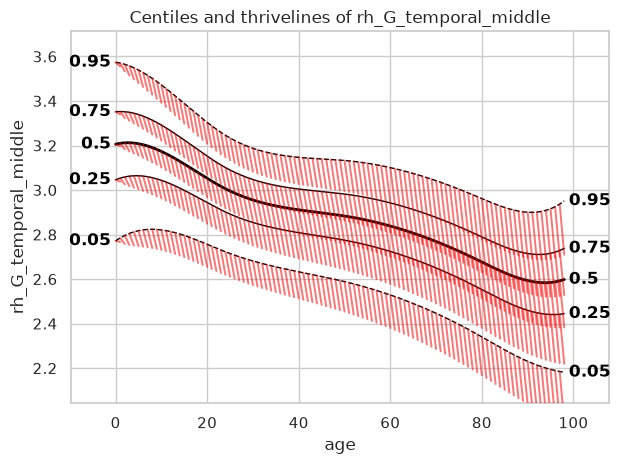

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:30:01 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:30:01 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:30:01 - Computing centiles for rh_Lat_Fis-ant-Horizont.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


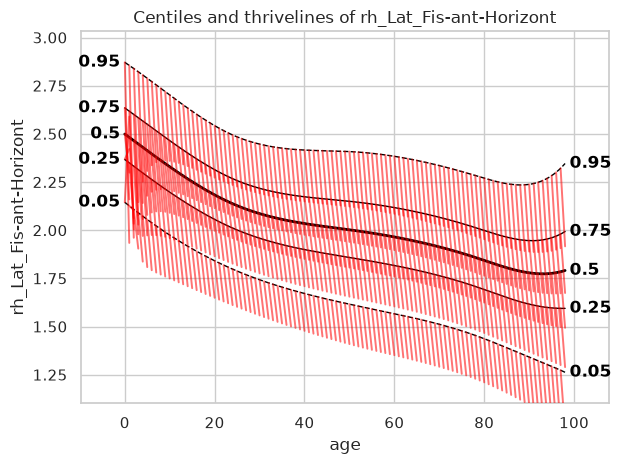

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:30:37 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:30:37 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:30:37 - Computing centiles for rh_Lat_Fis-ant-Vertical.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


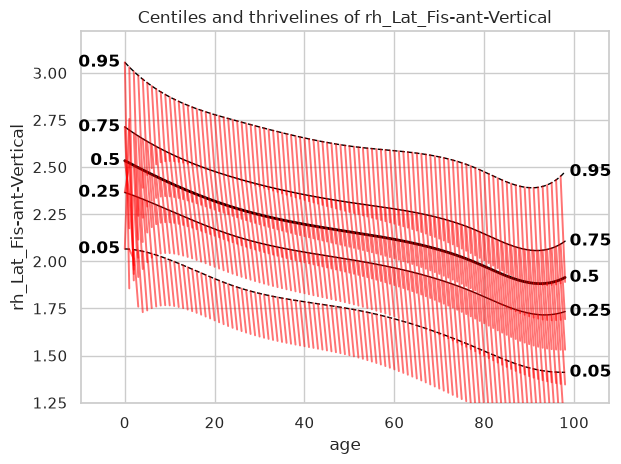

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:31:12 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:31:12 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:31:12 - Computing centiles for rh_Lat_Fis-post.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


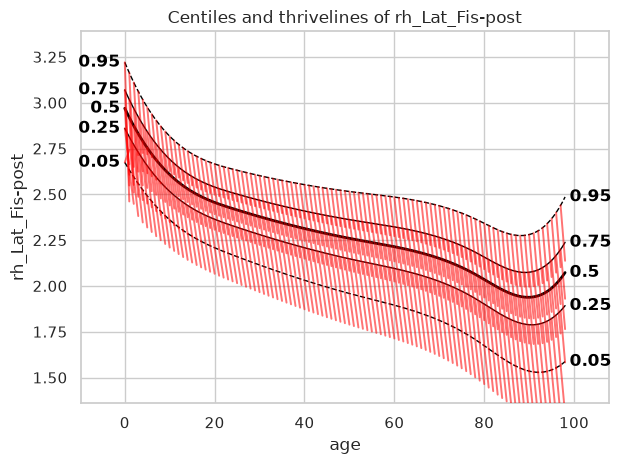

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:31:47 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:31:47 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:31:47 - Computing centiles for rh_Pole_occipital.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


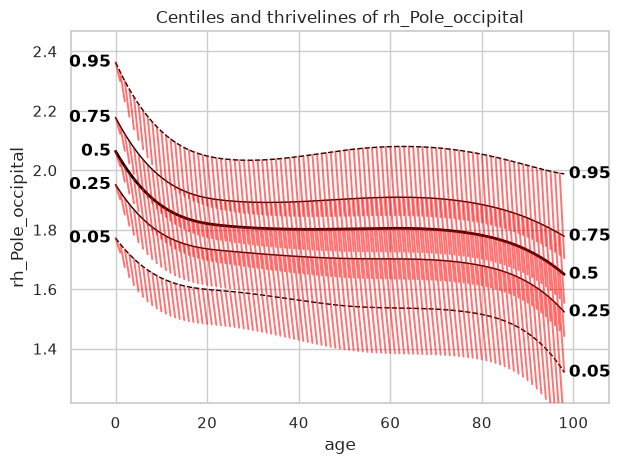

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:32:22 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:32:22 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:32:22 - Computing centiles for rh_Pole_temporal.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


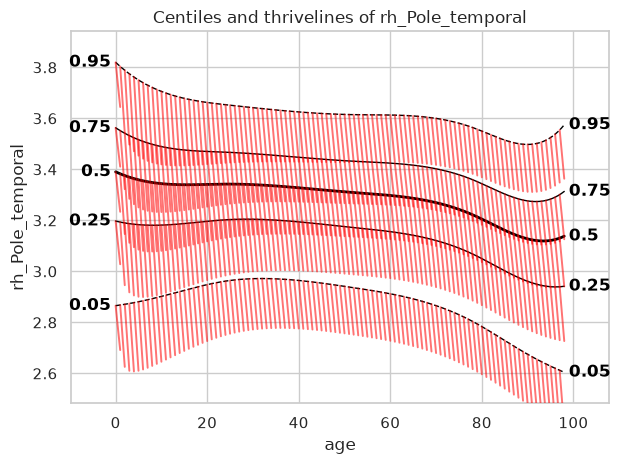

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:32:56 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:32:56 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:32:56 - Computing centiles for rh_S_calcarine.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


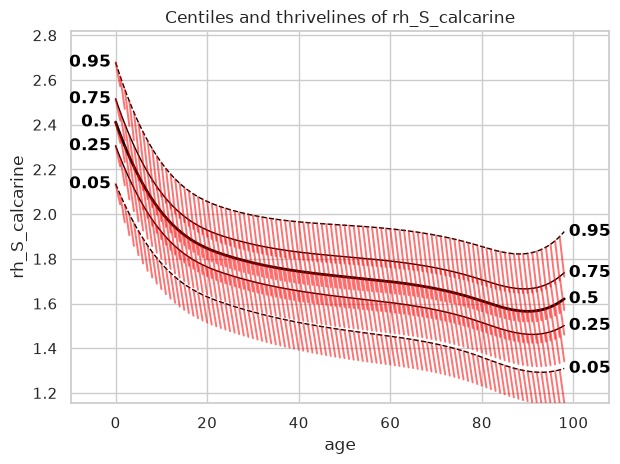

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:33:32 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:33:32 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:33:32 - Computing centiles for rh_S_central.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


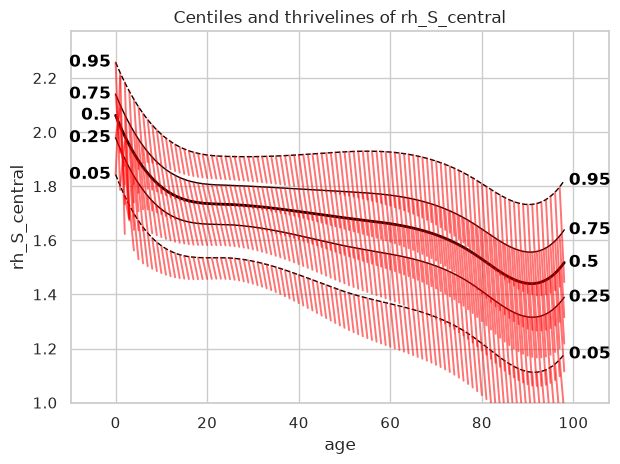

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:34:07 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:34:07 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:34:07 - Computing centiles for rh_S_cingul-Marginalis.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


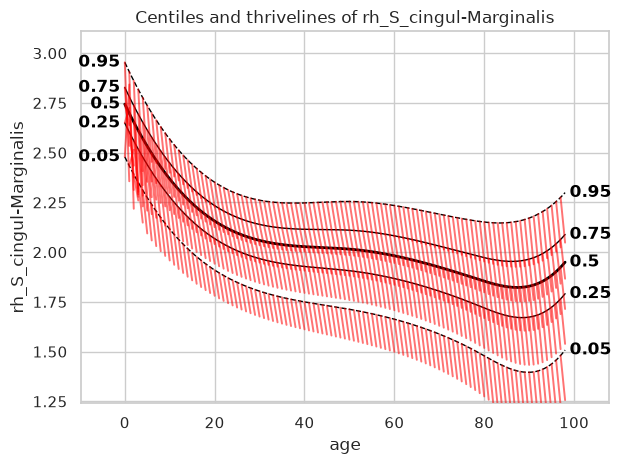

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:34:41 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:34:41 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:34:41 - Computing centiles for rh_S_circular_insula_ant.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


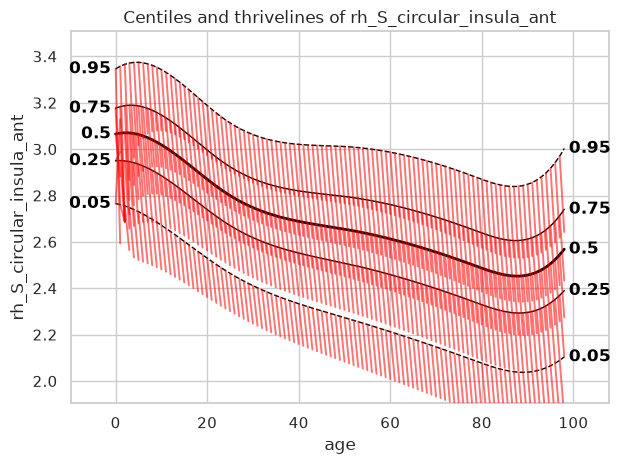

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:35:16 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:35:16 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:35:16 - Computing centiles for rh_S_circular_insula_inf.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


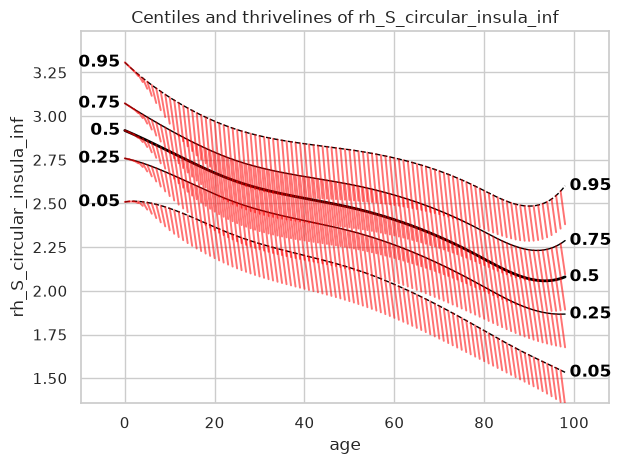

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:35:50 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:35:50 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:35:50 - Computing centiles for rh_S_circular_insula_sup.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


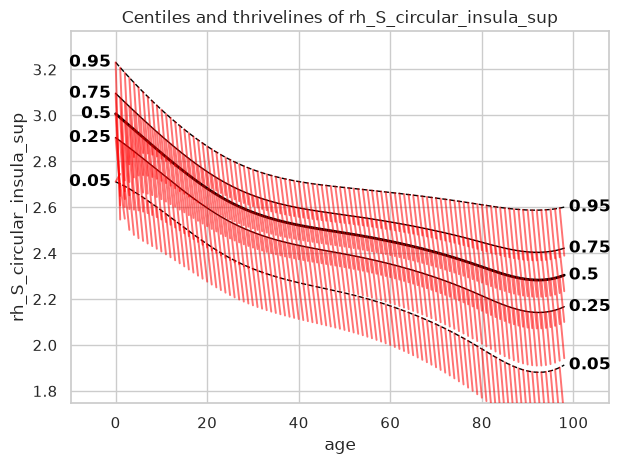

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:36:26 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:36:26 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:36:26 - Computing centiles for rh_S_collat_transv_ant.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


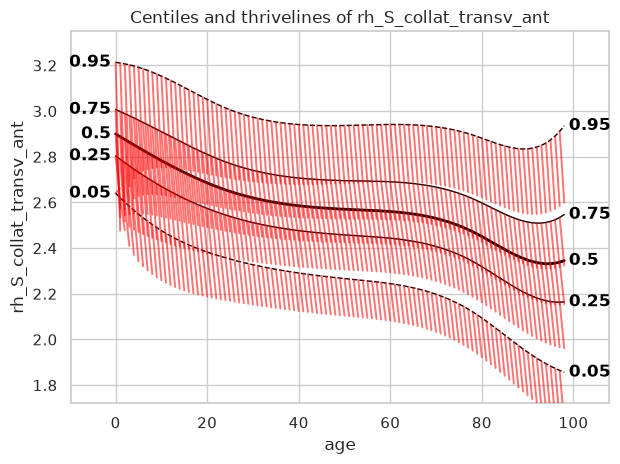

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:37:00 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:37:00 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:37:00 - Computing centiles for rh_S_collat_transv_post.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


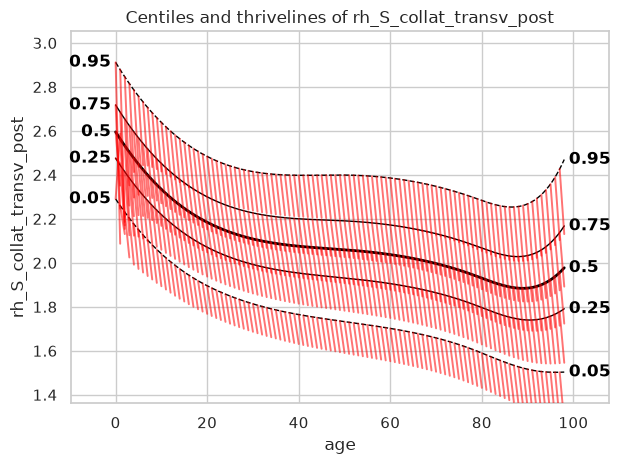

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:37:34 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:37:34 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:37:34 - Computing centiles for rh_S_front_inf.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


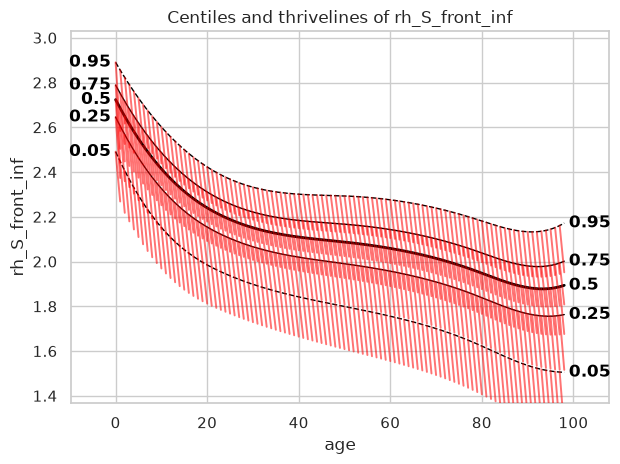

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:38:09 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:38:09 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:38:09 - Computing centiles for rh_S_front_middle.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


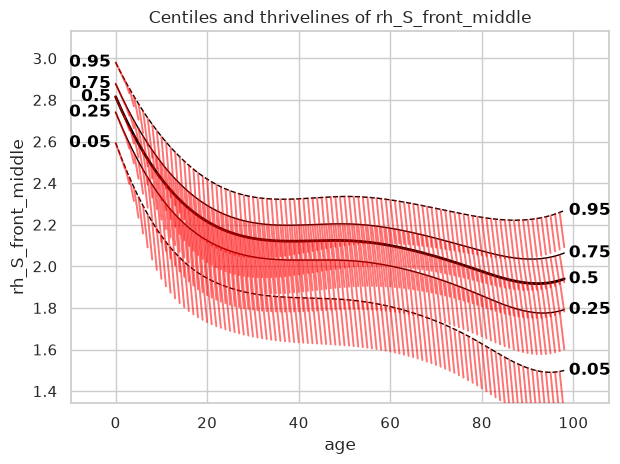

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:38:43 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:38:43 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:38:43 - Computing centiles for rh_S_front_sup.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


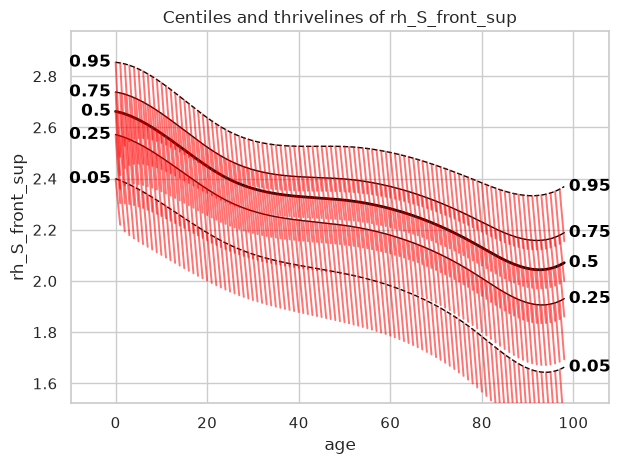

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:39:18 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:39:18 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:39:18 - Computing centiles for rh_S_interm_prim-Jensen.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


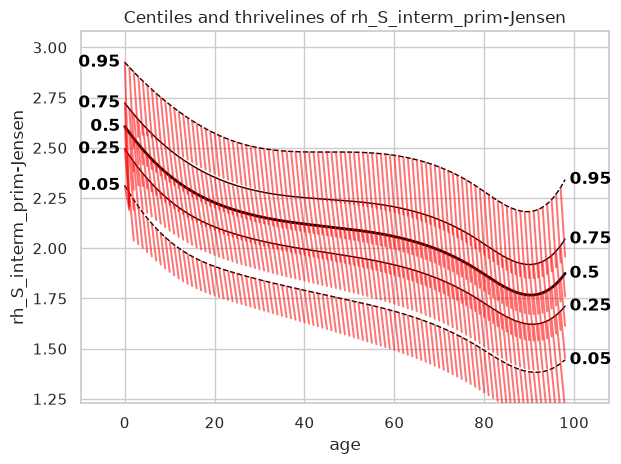

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:39:54 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:39:54 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:39:54 - Computing centiles for rh_S_intrapariet_and_P_trans.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


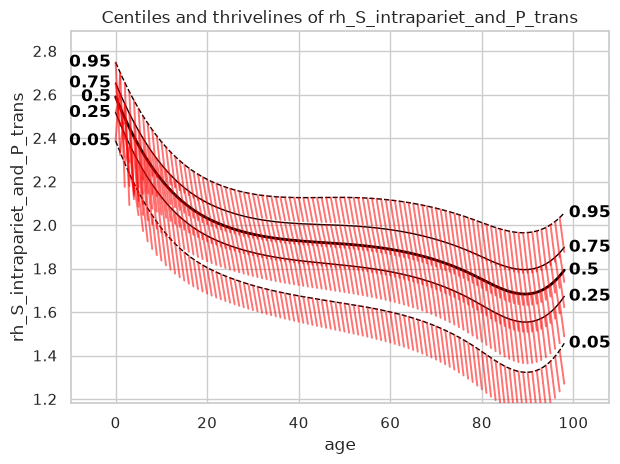

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:40:29 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:40:29 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:40:29 - Computing centiles for rh_S_oc_middle_and_Lunatus.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


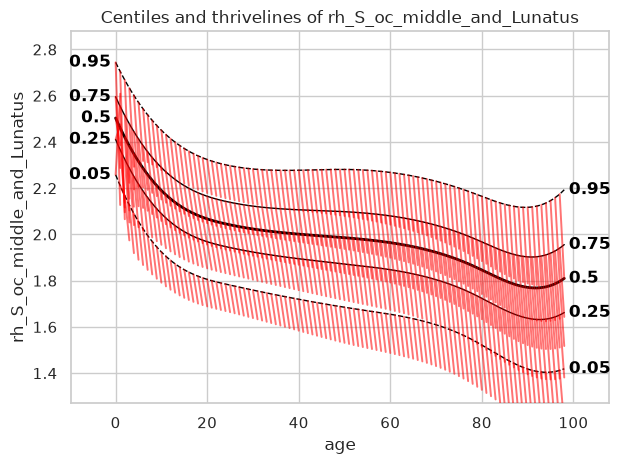

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:41:04 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:41:04 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:41:04 - Computing centiles for rh_S_oc_sup_and_transversal.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


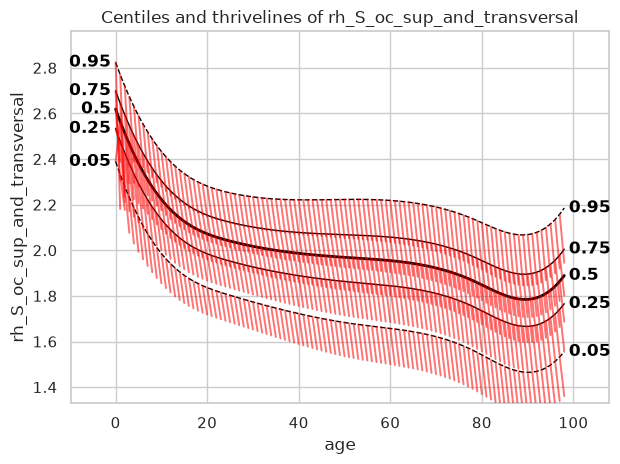

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:41:38 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:41:38 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:41:38 - Computing centiles for rh_S_occipital_ant.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


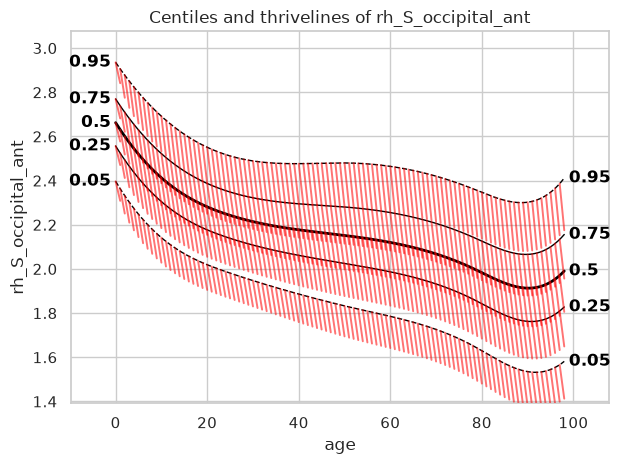

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:42:12 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:42:12 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:42:12 - Computing centiles for rh_S_oc-temp_lat.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


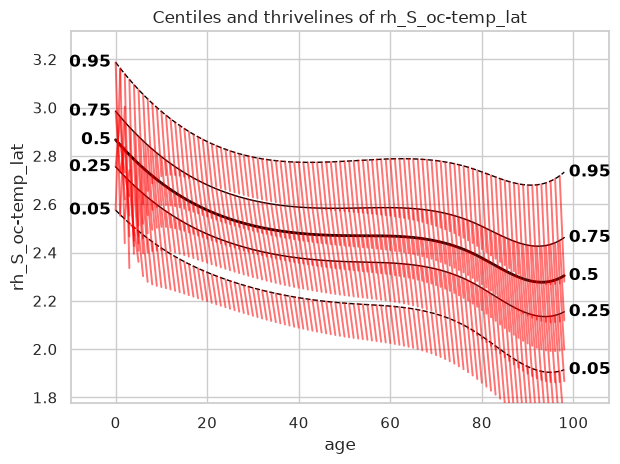

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:42:49 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:42:49 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:42:49 - Computing centiles for rh_S_oc-temp_med_and_Lingual.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


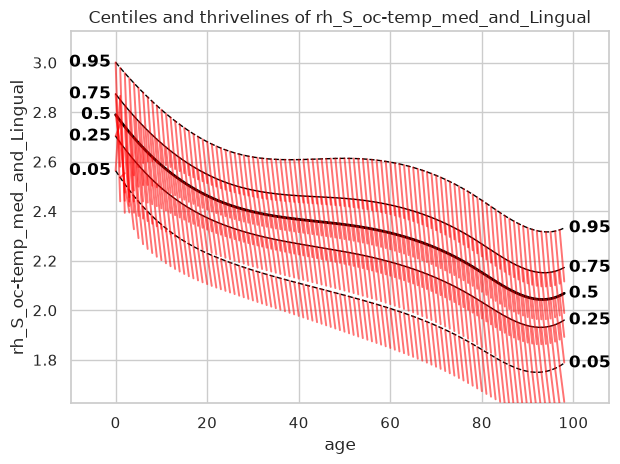

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:43:25 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:43:25 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:43:25 - Computing centiles for rh_S_orbital_lateral.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


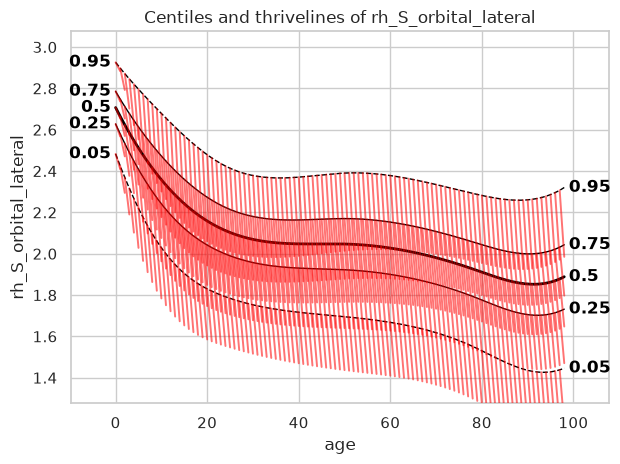

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:44:00 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:44:00 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:44:00 - Computing centiles for rh_S_orbital_med-olfact.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


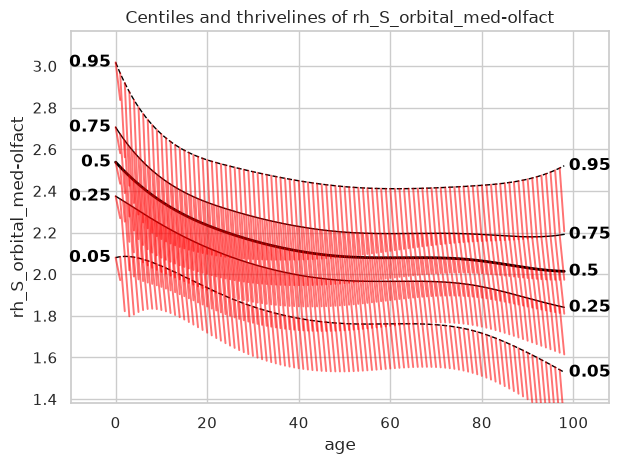

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:44:34 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:44:34 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:44:34 - Computing centiles for rh_S_orbital-H_Shaped.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


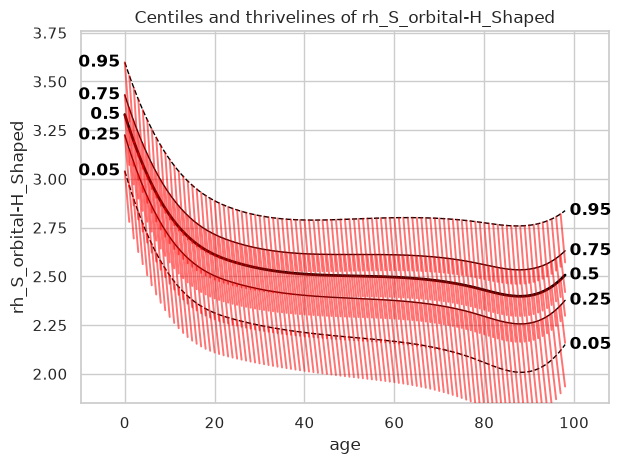

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:45:09 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:45:09 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:45:09 - Computing centiles for rh_S_parieto_occipital.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


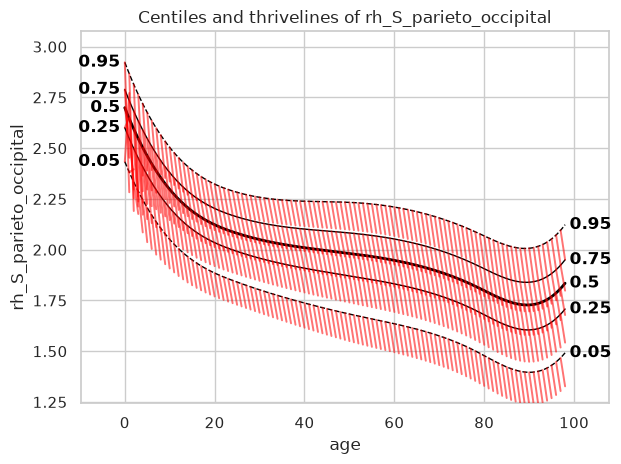

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:45:43 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:45:43 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:45:43 - Computing centiles for rh_S_pericallosal.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


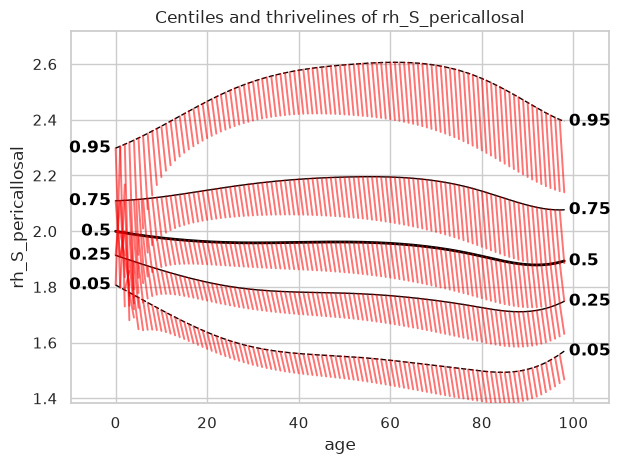

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:46:20 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:46:20 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:46:20 - Computing centiles for rh_S_postcentral.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


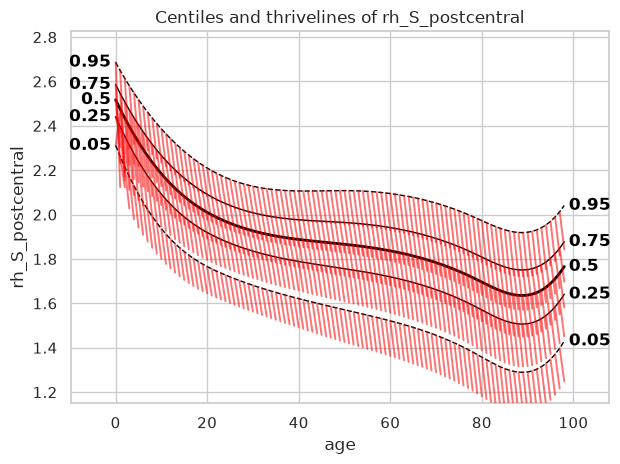

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:46:54 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:46:54 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:46:54 - Computing centiles for rh_S_precentral-inf-part.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


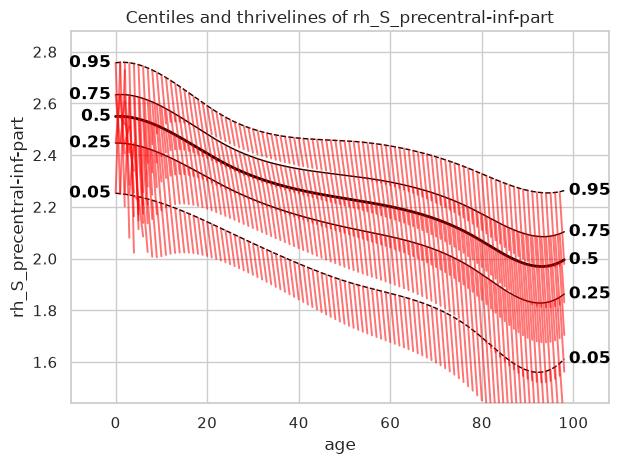

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:47:28 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:47:28 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:47:28 - Computing centiles for rh_S_precentral-sup-part.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


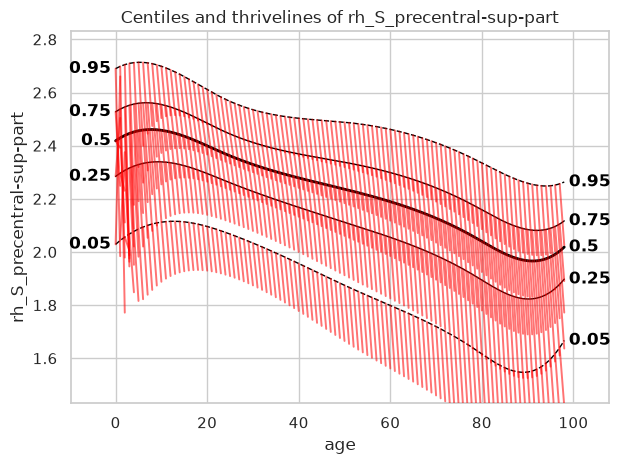

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:48:02 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:48:02 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:48:02 - Computing centiles for rh_S_suborbital.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


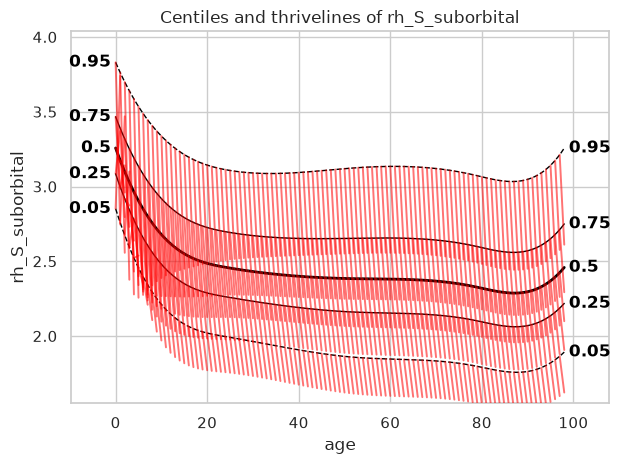

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:48:36 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:48:36 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:48:36 - Computing centiles for rh_S_subparietal.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


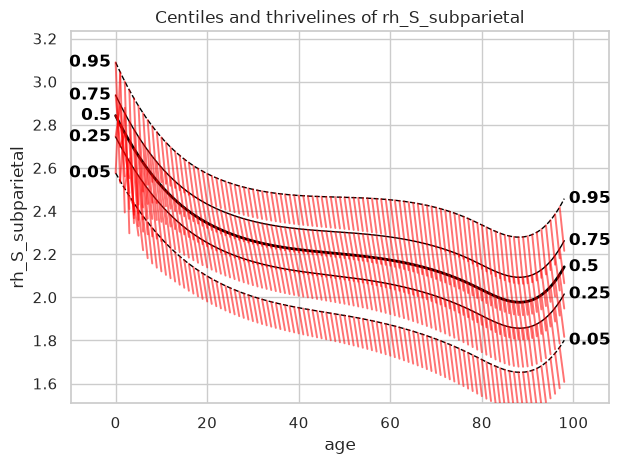

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:49:14 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:49:14 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:49:14 - Computing centiles for rh_S_temporal_inf.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


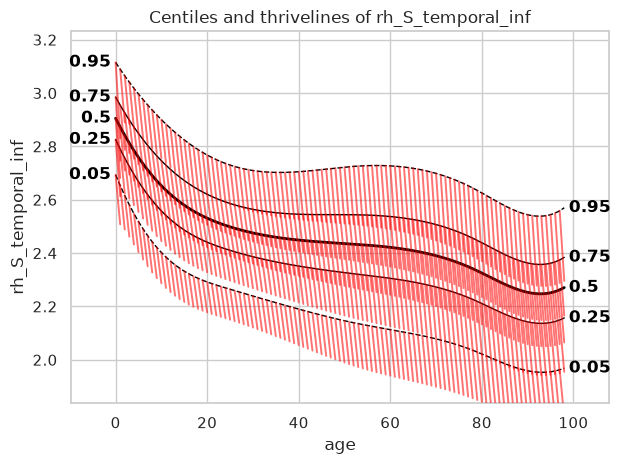

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:49:51 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:49:51 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:49:51 - Computing centiles for rh_S_temporal_sup.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


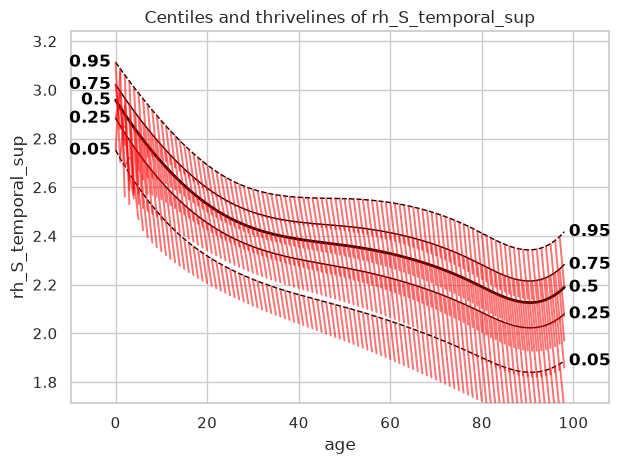

Sampling: []
Sampling: []


Process: 2057996 - 2026-09-11 22:50:26 - Dataset "centile" created.
    - 150 observations
    - 150 unique subjects
    - 1 covariates
    - 1 response variables
    - 2 batch effects:
    	sex (1)
	site_id2 (1)
    
Process: 2057996 - 2026-09-11 22:50:27 - Computing centiles for 1 response variables.
Process: 2057996 - 2026-09-11 22:50:27 - Computing centiles for rh_S_temporal_transverse.


Sampling: []
Sampling: []
Sampling: []
Sampling: []
Sampling: []


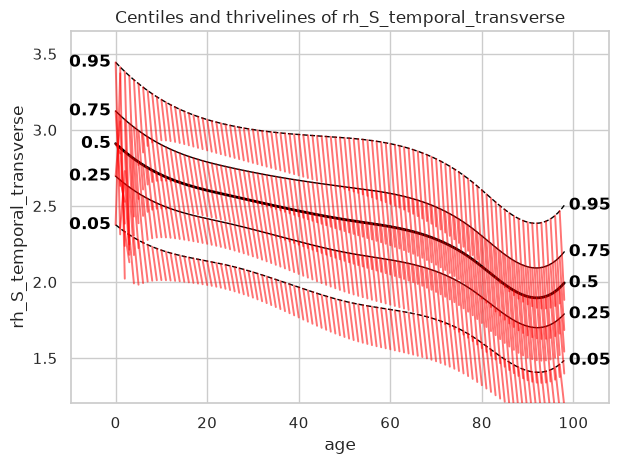

FileNotFoundError: [Errno 2] No such file or directory: '/project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity/Velocity_models/DES_demented/batch_149_Mean_Thickness/Velocity/velocity_objects_new_Oct25.pkl'

In [12]:
for i, response_vars in enumerate(features_to_model[103:]):
    i=i+103
    MATRIX_PATH = (
        f"/project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity/Velocity_models/DES_demented/batch_{i+1}_{response_vars}/Velocity/velocity_objects_new_Oct25.pkl"
    )
    
    # The region is read from the batch_1_lh_G_and_S_frontomargin directory.
    corr = CorrelationMatrix.load(MATRIX_PATH)
    REGION = str(corr.matrix.coords["response_vars"].values[0])

    centiles = [0.05, 0.25, 0.5, 0.75, 0.95]

    thrivelines = ZGainScore(model, corr).get_thrivelines(
        z_anchors=stats.norm.ppf(centiles),
    )
    
    import matplotlib.pyplot as plt
    import warnings
    warnings.filterwarnings("ignore") 
    plot_thrivelines(
        model,
        thrivelines=thrivelines,
        centiles=centiles,
        covariate="age",
        response_vars=[REGION],
        save_dir ='/project_cephfs/3022017.06/projects/lifespan_hbr/johbay/Velocity/CODE_new/revision/thriveline_plots/'
    )
